**change runtime and connect with T4 (for faster execution)**

Important Libraries



In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dropout,Dense,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Dataset Name

# **Cats vs Dogs dataset (from TensorFlow Datasets)**

**Properties**
Type: Image Classification Dataset
Classes: 2 (Cat, Dog)

**Labels:**
0 → Cat
1 → Dog

**Data Split**
80% → Training set
10% → Validation set
10% → Test set (final evaluation)

# Image Details

RGB images (3 channels)
Variable image size

In [2]:
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,as_supervised=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.GNHPFE_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [3]:
print('Total training samples: ', tf.data.experimental.cardinality(train_ds).numpy())
print('Total test samples: ', tf.data.experimental.cardinality(test_ds).numpy())

Total training samples:  18610
Total test samples:  2326


In [4]:
img_size = 512          # 512 * 512
batch_size = 32         #32 samples per batch

def preprocess(image, label):
    image = tf.image.resize(image, (img_size, img_size)) # resize the image in 512 * 512 size
    image = image / 255.0  # normalized (0-1) range
    return image, label

train_generator = train_ds.map(preprocess).batch(batch_size).prefetch(1)
val_generator = val_ds.map(preprocess).batch(batch_size).prefetch(1)
test_generator  = test_ds.map(preprocess).batch(batch_size).prefetch(1)

In [5]:
import matplotlib.pyplot as plt
class_names = ['Cat', 'Dog']  # cat close to 0 and dog close to 1
def show_image(index, dataset):

  for image, label in dataset.skip(index).take(1):

    # preprocess for display
    image_resized = tf.image.resize(image, [img_size,img_size]) / 255.0
    plt.figure(figsize=(4,4))
    plt.imshow(image_resized)
    plt.title(
        f"Index: {index}\nLabel: {class_names[int(label)]}"
    )
    plt.axis('off')


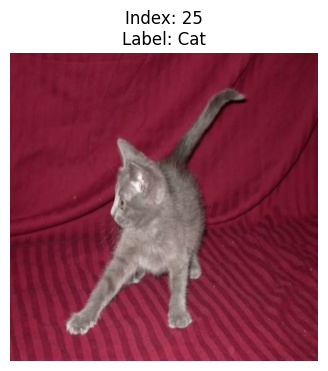

In [6]:
show_image(25, train_ds)   # 25 numeber image from the test dataset

In [7]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(512, 512, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 510, 510, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 492032)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    62,980,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,073,601 (240.61 MB)

 Trainable params: 63,073,601 (240.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 195s 299ms/step - accuracy: 0.6065 - loss: 0.7319 - val_accuracy: 0.6617 - val_loss: 0.6243
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 156s 268ms/step - accuracy: 0.6946 - loss: 0.5847 - val_accuracy: 0.6797 - val_loss: 0.6131
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 157s 269ms/step - accuracy: 0.7628 - loss: 0.4901 - val_accuracy: 0.6896 - val_loss: 0.7133
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 155s 267ms/step - accuracy: 0.8343 - loss: 0.3779 - val_accuracy: 0.6758 - val_loss: 0.9056
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 158s 271ms/step - accuracy: 0.8890 - loss: 0.2655 - val_accuracy: 0.6758 - val_loss: 1.0096
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 156s 268ms/step - accuracy: 0.9271 - loss: 0.1950 - val_accuracy: 0.6784 - val_loss: 1.0510
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 156s 267ms/step - accuracy: 0.9452 - loss: 0.1521 - val_accuracy: 0.6750 - val_loss: 1.3334
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 157s 269ms/step - accuracy: 0.9564 -

In [10]:
loss, accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy : {accuracy * 100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.6866 - loss: 1.4891

Test Accuracy : 68.66%
Test Loss     : 1.4891


Saving dg.webp to dg.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
DOG  (confidence: 99.9%)


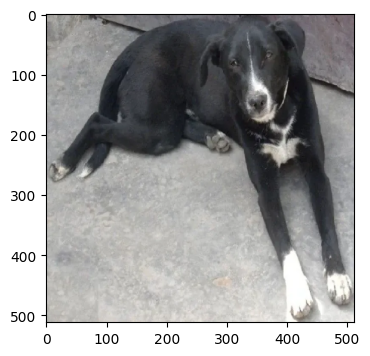

In [17]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = image.load_img(filename, target_size=(512, 512))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
plt.figure(figsize=(4,4))
plt.imshow(img_array[0])
pred = model.predict(img_array)[0][0]

if pred > 0.5:
    print(f"DOG  (confidence: {pred*100:.1f}%)")
else:
    print(f"CAT  (confidence: {(1-pred)*100:.1f}%)")

